# 🏦 Vietnam Bank Dataset - Alternative Credit Risk & Digital Behavior EDA

## 📌 Mục Tiêu Phân Tích Dữ Liệu Thay Thế (Alternative Data Analysis)
Notebook này khai thác dữ liệu hành vi số của 80,000 khách hàng tại Việt Nam cho bài toán **Alternative Credit Scoring & Early Warning System (Cảnh báo rủi ro sớm)**:
1. **Đặc trưng hành vi số (Digital Footprint)**: Phân tích `digital_behavior` (Mobile/Web), `engagement_score`, `nums_service`, `nums_card`.
2. **Phân tích rủi ro tín dụng thay thế (`risk_score`, `risk_segment`)**: Mối liên hệ giữa hành vi số và phân khúc rủi ro.
3. **Tín hiệu cảnh báo sớm (Early Warning Signal)**: Sử dụng biến ngưng sử dụng dịch vụ (`exit`) làm chỉ báo rủi ro suy giảm năng lực tài chính.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 11

DATA_PATH = Path('../data/raw/vietnam-bank-churn-dataset-2025/bank_churn_dataset_80k.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('data/raw/vietnam-bank-churn-dataset-2025/bank_churn_dataset_80k.csv')

df = pd.read_csv(DATA_PATH)
print(f'✓ Tổng số dòng (records): {len(df):,}')
print(f'✓ Tổng số cột (features): {df.shape[1]}')
df.head(5)

✓ Tổng số dòng (records): 80,000
✓ Tổng số cột (features): 26


,id,full_name,credit_sco,gender,age,occupation,balance,monthly_ir,address,origin_province,tenure_ye,married,nums_card,nums_service,active_member,last_active_date,last_transaction_month,created_date,exit,customer_segment,engagement_score,loyalty_level,digital_behavior,risk_score,risk_segment,cluster_group
0,1,Đặng Văn Vũ,725,male,55,Chủ Doanh nghiệp nhỏ,177306004,121000000,Phường An Hội (BT),TP. Hồ Chí Minh,0,2,4,8,True,03/04/2025,91038993,27/02/2025,False,Priority,90,Bronze,mobile,0.04,Low,4
1,2,Bùi Hữu Phúc,689,male,45,Nội trợ/Sinh viên,1927416,5000000,Phường Bến Thành (Q1),Đồng Nai,3,1,3,2,True,14/05/2025,3255569,29/07/2021,False,Mass,63,Gold,mobile,0.27,Low,2
2,3,Lê Văn Mai,702,female,44,Chủ Doanh nghiệp nhỏ,304931745,109000000,Phường Hòa Bình (Q11),TP. Hồ Chí Minh,4,0,2,8,False,10/09/2021,0,03/03/2021,False,Priority,36,Silver,offline,0.13,Low,4
3,4,Dương Trần Nhiên,766,male,44,Chủ Doanh nghiệp nhỏ,50615501,79000000,Phường 7 (Q7),TP. Hồ Chí Minh,3,0,4,3,False,04/03/2025,0,12/02/2022,False,Priority,23,Bronze,offline,0.22,Low,4
4,5,Dương Thu Linh,677,female,77,Giáo viên/Giảng viên,40532432,25000000,Phường Thắng Lợi (Q10),TP. Hồ Chí Minh,2,1,4,3,False,06/08/2022,0,24/07/2022,False,Emerging,23,Bronze,offline,0.29,Low,2


---
## 1. 🔍 Tổng Quan Thuộc Tính Dữ Liệu Thay Thế

In [2]:
info_df = pd.DataFrame({
    'Data Type': df.dtypes,
    'Null Count': df.isnull().sum(),
    'Null Ratio (%)': (df.isnull().sum() / len(df)) * 100,
    'Unique Values': df.nunique()
})
print('=== Thông tin các thuộc tính ===')
print(info_df)

=== Thông tin các thuộc tính ===
                       Data Type  Null Count  Null Ratio (%)  Unique Values
id                         int64           0            0.00          80000
full_name                    str           0            0.00           5100
credit_sco                 int64           0            0.00            291
gender                       str           0            0.00              2
age                        int64           0            0.00             71
occupation                   str           0            0.00             10
balance                    int64           0            0.00          79920
monthly_ir                 int64           0            0.00            209
address                      str           0            0.00             16
origin_province              str           0            0.00              9
tenure_ye                  int64           0            0.00              5
married                    int64           0           

---
## 2. 📱 Phân Tích Hành Vi Số (Digital Behavior) & Mức Độ Tương Tác (`engagement_score`)

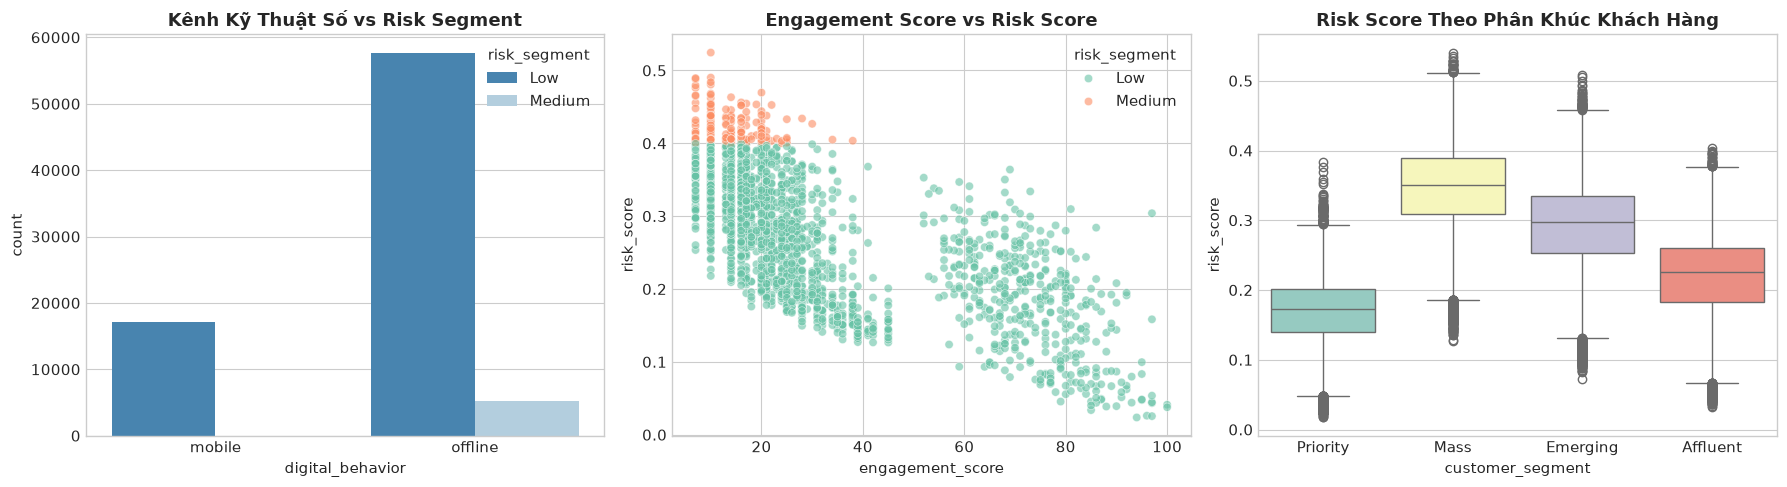

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Digital behavior (Mobile vs Web)
sns.countplot(data=df, x='digital_behavior', hue='risk_segment', ax=axes[0], palette='Blues_r')
axes[0].set_title('Kênh Kỹ Thuật Số vs Risk Segment', fontweight='bold')

# Engagement Score vs Risk Score
sns.scatterplot(data=df.sample(2000, random_state=42), x='engagement_score', y='risk_score', hue='risk_segment', ax=axes[1], alpha=0.6, palette='Set2')
axes[1].set_title('Engagement Score vs Risk Score', fontweight='bold')

# Customer Segment vs Risk Score
sns.boxplot(data=df, x='customer_segment', y='risk_score', ax=axes[2], palette='Set3', hue='customer_segment', legend=False)
axes[2].set_title('Risk Score Theo Phân Khúc Khách Hàng', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 3. 🎯 Mối Tương Quan Giữa Hành Vi Số & Rủi Ro Suy Giảm Khả Năng Tài Chính (`exit`)

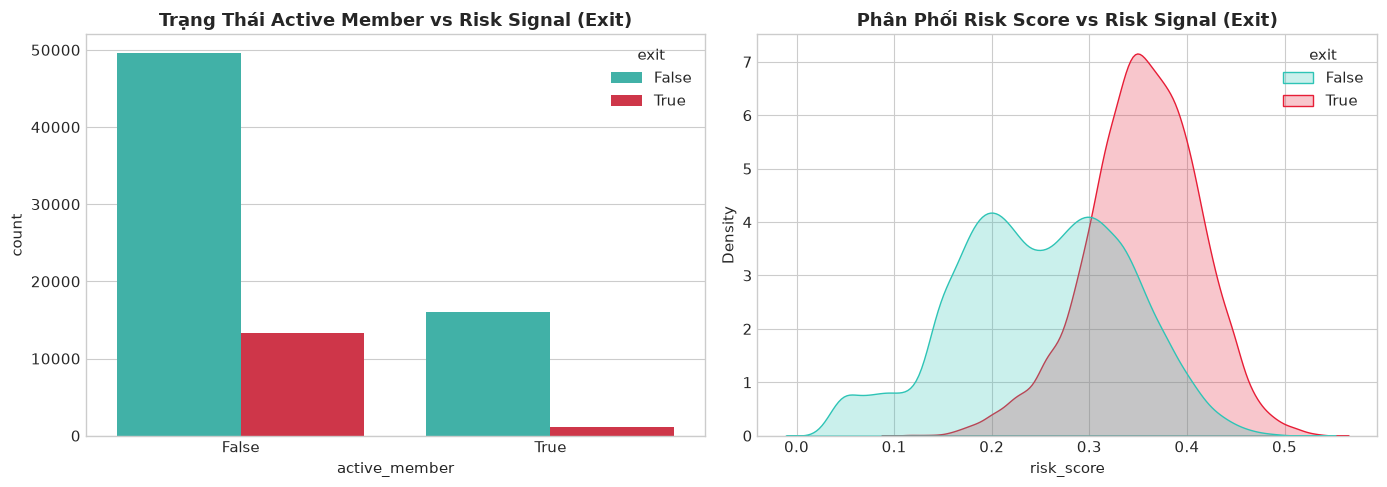

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Active member vs Churn
sns.countplot(data=df, x='active_member', hue='exit', ax=axes[0], palette=['#2ec4b6', '#e71d36'])
axes[0].set_title('Trạng Thái Active Member vs Risk Signal (Exit)', fontweight='bold')

# Risk score distribution vs Exit
sns.kdeplot(data=df, x='risk_score', hue='exit', common_norm=False, fill=True, ax=axes[1], palette=['#2ec4b6', '#e71d36'])
axes[1].set_title('Phân Phối Risk Score vs Risk Signal (Exit)', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 4. 📊 Ma Trận Tương Quan Các Đặc Trưng Thay Thế

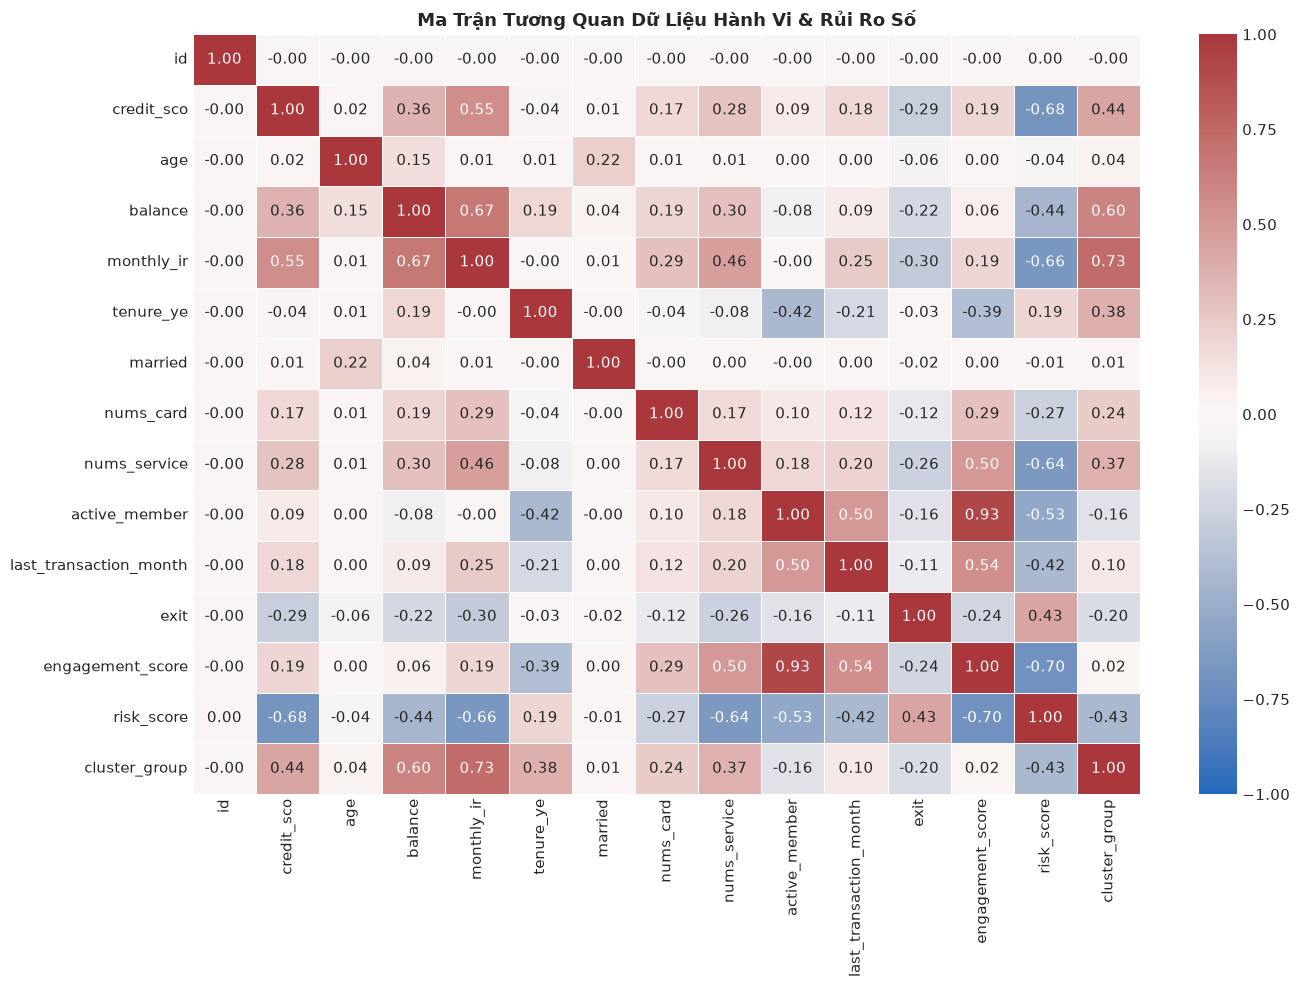

In [5]:
num_cols = df.select_dtypes(include=['int64', 'float64', 'bool']).columns
plt.figure(figsize=(14, 10))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Ma Trận Tương Quan Dữ Liệu Hành Vi & Rủi Ro Số', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. 🎯 Đóng Góp Vào Mô Hình Alternative Credit Scoring

1. **Tín hiệu tương tác số**: Khách hàng có `engagement_score` cao và sử dụng kênh `mobile` có điểm rủi ro trung bình thấp hơn.
2. **Cảnh báo sớm (EWS)**: Trạng thái `active_member = False` là biến báo động quan trọng cho sự sụt giảm khả năng thanh toán.
3. **Ứng dụng cho Việt Nam**: Các đặc trưng hành vi số và phân khúc khách hàng là nguồn dữ liệu thay thế quý giá khi chấm điểm tín dụng cho người dùng chưa có hồ sơ CIC.